# Learning Style Classification Training

This notebook trains a production-ready learning style classifier using `Student_Performance.xlsx`, evaluates it with multiple metrics, visualizes results, and saves reusable Joblib artifacts for the Streamlit app.


In [19]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [20]:
TARGET_COLUMN = "Learning Style"
RANDOM_STATE = 42

dataset_candidates = [
    Path("Student_Performance.xlsx"),
    Path("./Student_Performance.xlsx"),
]

for candidate in dataset_candidates:
    if candidate.exists():
        DATASET_PATH = candidate.resolve()
        break
else:
    raise FileNotFoundError("Student_Performance.xlsx was not found in the project directory.")

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODELS_DIR / "learning_style_model.pkl"
PREPROCESSOR_PATH = MODELS_DIR / "preprocessor.pkl"

df = pd.read_excel(DATASET_PATH)
print(f"Dataset loaded from: {DATASET_PATH}")
print(f"Shape: {df.shape}")


Dataset loaded from: C:\Akira\University Stuff\Sem 2\1. AIML\AI Lab\AIML Project\prototype\Student_Performance.xlsx
Shape: (10000, 41)


In [21]:
if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' not found in dataset.")

display(df.head())
display(df.info())
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values").head(20))
display(df[TARGET_COLUMN].value_counts(dropna=False).to_frame("count"))


,Student ID,Gender,Age,Grade Level,Attendance Rate,Study Hours,Parental Education Level,Parental Involvement,Extracurricular Activities,Socioeconomic Status,Previous Academic Performance,Class Participation,Health Status,Access to Learning Resources,Internet Access,Learning Style,Teacher-Student Relationship,Peer Influence,Motivation Level,Hours of Sleep,Diet Quality,Transportation Mode,School Type,School Location,Homework Completion Rate,Reading Proficiency,Math Proficiency,Science Proficiency,Language Proficiency,Physical Activity Level,Screen Time,Bullying Incidents,Special Education Services,Counseling Services,Learning Disabilities,Behavioral Issues,Attendance of Tutoring Sessions,School Climate,Parental Employment Status,Household Size,Performance Score
0,1,Male,15,12,80.487800,2.764496,Bachelor's,High,Yes,High,66.661594,Low,Good,No,Yes,Visual,Positive,Negative,Medium,6.485613,Poor,Bus,Public,Urban,86.568323,99.570689,86.725129,60.785049,90.309659,Low,3.068109,1,No,Yes,Yes,Yes,No,Negative,Unemployed,3,Low
1,2,Female,17,12,96.242678,4.534785,Bachelor's,High,Yes,Low,79.129923,High,Poor,No,No,Visual,Positive,Negative,Medium,5.973091,Poor,Bus,Private,Rural,84.184009,85.818975,66.528350,64.268164,97.812943,Low,1.400854,3,Yes,Yes,No,Yes,No,Negative,Employed,3,Medium
2,3,Male,14,9,84.649681,2.008148,Bachelor's,Medium,Yes,Low,98.070597,High,Poor,Yes,Yes,Kinesthetic,Negative,Positive,High,7.740244,Poor,Bus,Private,Rural,76.310262,84.520809,94.547802,86.117803,69.853971,High,3.929084,0,Yes,No,Yes,No,No,Neutral,Employed,3,High
3,4,Male,14,10,86.158599,3.698293,High School,High,No,Low,74.937204,Low,Good,No,Yes,Visual,Positive,Neutral,Low,7.995529,Average,Bus,Public,Urban,64.108944,97.496243,62.906840,82.763513,96.601016,High,2.789854,3,Yes,No,No,Yes,No,Positive,Employed,4,Medium
4,5,Male,15,10,88.487638,3.408604,Associate,Low,No,Middle,67.129520,Medium,Fair,No,Yes,Visual,Neutral,Neutral,Medium,8.864511,Average,Car,Private,Rural,84.945985,94.444113,76.347470,84.983862,70.108607,Medium,2.790160,1,Yes,Yes,No,No,No,Positive,Employed,6,Low


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student ID                       10000 non-null  int64  
 1   Gender                           10000 non-null  str    
 2   Age                              10000 non-null  int64  
 3   Grade Level                      10000 non-null  int64  
 4   Attendance Rate                  10000 non-null  float64
 5   Study Hours                      10000 non-null  float64
 6   Parental Education Level         10000 non-null  str    
 7   Parental Involvement             10000 non-null  str    
 8   Extracurricular Activities       10000 non-null  str    
 9   Socioeconomic Status             10000 non-null  str    
 10  Previous Academic Performance    10000 non-null  float64
 11  Class Participation              10000 non-null  str    
 12  Health Status                 

None

,missing_values
Student ID,0
Gender,0
Age,0
Grade Level,0
Attendance Rate,0
Study Hours,0
Parental Education Level,0
Parental Involvement,0
Extracurricular Activities,0
Socioeconomic Status,0


,count
Learning Style,
Visual,4662
Kinesthetic,3261
Auditory,2077


In [22]:
X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", X.shape[1])


Numeric features: 15
Categorical features: 25
Total features: 40


In [23]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train.shape, "->", X_train_processed.shape)
print("Test shape:", X_test.shape, "->", X_test_processed.shape)


Train shape: (8000, 40) -> (8000, 81)
Test shape: (2000, 40) -> (2000, 81)


In [24]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted"),
    "MCC": matthews_corrcoef(y_test, y_pred),
    "Cohen Kappa": cohen_kappa_score(y_test, y_pred),
    "Log Loss": log_loss(y_test, y_proba, labels=model.classes_),
}

metrics_df = pd.DataFrame(
    {
        "Metric": list(metrics.keys()),
        "Value": list(metrics.values()),
    }
)
display(metrics_df)


,Metric,Value
0,Accuracy,0.878500
1,Balanced Accuracy,0.852361
2,Precision,0.881758
3,Recall,0.878500
4,F1 Score,0.876909
5,ROC-AUC,0.979137
6,MCC,0.807738
7,Cohen Kappa,0.804401
8,Log Loss,0.485276


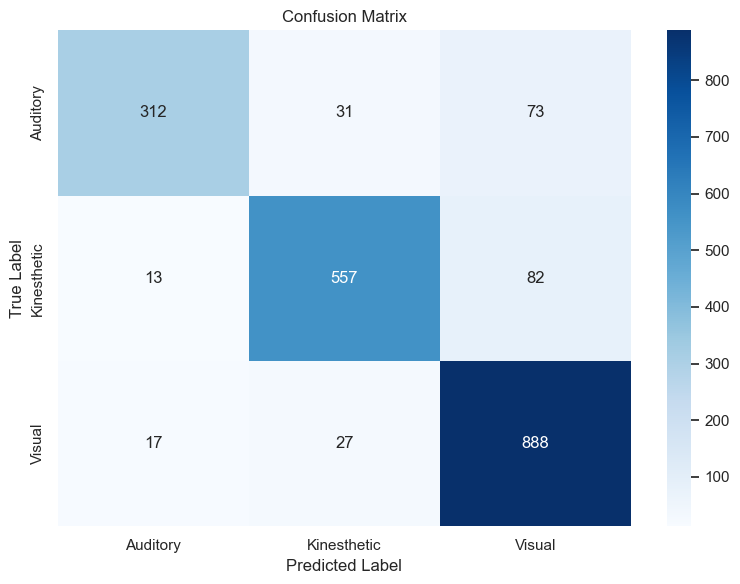

In [25]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


,feature,importance
30,Class Participation_High,0.088591
8,Reading Proficiency,0.085324
11,Language Proficiency,0.078444
60,Physical Activity Level_High,0.058519
10,Science Proficiency,0.039005
9,Math Proficiency,0.038339
7,Homework Completion Rate,0.033610
42,Teacher-Student Relationship_Positive,0.030880
25,Extracurricular Activities_No,0.030410
26,Extracurricular Activities_Yes,0.027909


C:\Users\Raghav\AppData\Local\Temp\ipykernel_18708\1444609570.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


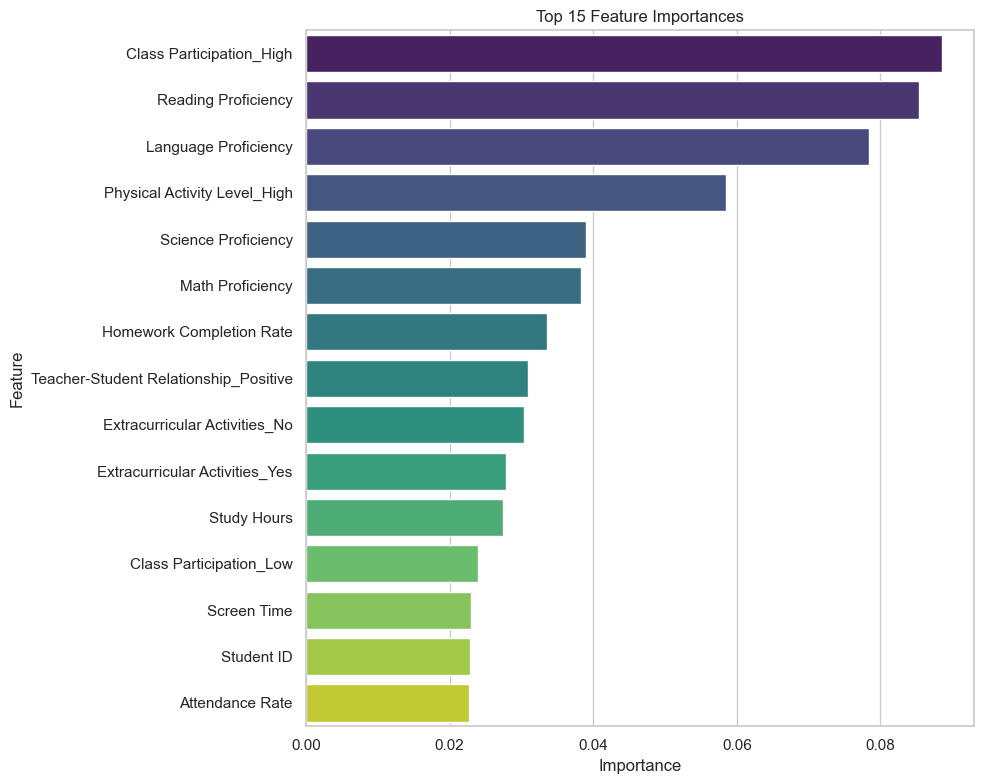

In [26]:
feature_importances = pd.DataFrame(
    {
        "feature": preprocessor.get_feature_names_out(),
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importances.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importances.head(15),
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [27]:
# Store metadata directly on the fitted preprocessor so the app can rebuild forms and validations.
preprocessor.feature_columns_ = X.columns.tolist()
preprocessor.numeric_features_ = numeric_features
preprocessor.categorical_features_ = categorical_features
preprocessor.target_column_ = TARGET_COLUMN
preprocessor.class_names_ = model.classes_.tolist()
preprocessor.train_shape_ = X_train.shape
preprocessor.test_shape_ = X_test.shape
preprocessor.random_state_ = RANDOM_STATE
preprocessor.model_name_ = type(model).__name__

joblib.dump(model, MODEL_PATH)
joblib.dump(preprocessor, PREPROCESSOR_PATH)

print(f"Saved model to: {MODEL_PATH.resolve()}")
print(f"Saved preprocessor to: {PREPROCESSOR_PATH.resolve()}")


Saved model to: C:\Akira\University Stuff\Sem 2\1. AIML\AI Lab\AIML Project\prototype\models\learning_style_model.pkl
Saved preprocessor to: C:\Akira\University Stuff\Sem 2\1. AIML\AI Lab\AIML Project\prototype\models\preprocessor.pkl
